In [30]:
import axios, { AxiosResponse } from 'axios';
import fs from "node:fs"
// Load .env file
import "@std/dotenv/load";
import { saveJson, inferType, toTsInterface } from "./utils.ts"

// this talks to internet so might not include this
// adapted from https://github.com/luke0x90/thegymgroup-api/blob/main/example.py
const baseHeaders = {
    "accept": "application/json",
    "accept-encoding": "gzip",
    "connection": "Keep-Alive",
    "host": "thegymgroup.netpulse.com",
    // "user-agent": "okhttp/3.12.3",
    // "x-np-api-version": "1.5",
    // "x-np-app-version": "6.0.1",
    "x-np-user-agent": "clientType=MOBILE_DEVICE; devicePlatform=ANDROID; deviceUid=; applicationName=The Gym Group; applicationVersion=5.0; applicationVersionCode=38"
};

interface LoginResponse {
    uuid: string;
}

interface GymGroupRawRecord {
    gymLocationName: string,
    gymLocationAddress: string,
    checkInDate: string,
    timezone: string,
    checkinId: string | null,
    expiresIn: string | null,
    duration: 1680000
}

interface CheckInsResponse {
    checkIns: GymGroupRawRecord[];
}



async function extract(creds: Record<string, string>): Promise<GymGroupRawRecord[]> {
    // Login request - let axios handle content-type and content-length
    const response: AxiosResponse<LoginResponse> = await axios.post(
        "https://thegymgroup.netpulse.com/np/exerciser/login",
        new URLSearchParams(creds),
        {
            headers: {
                ...baseHeaders,
                "content-type": "application/x-www-form-urlencoded"
            }
        }
    );

    const cookie = response.headers["set-cookie"]?.[0] || "";
    const userId = response.data.uuid;

    // Helper function to get URL
    async function getUrl(url: string): Promise<any> {
        const profile = await axios.get(url, {
            headers: {
                ...baseHeaders,
                "cookie": cookie
            }
        });
        return profile.data;
    }

    let mins = 0;
    const endDate = '2026-01-01T00:00:00';
    const visits: CheckInsResponse = await getUrl(
        `https://thegymgroup.netpulse.com/np/exercisers/${userId}/check-ins/history?endDate=${encodeURIComponent(endDate)}`
    );

    return visits.checkIns

}



const username = Deno.env.get("GYM_GROUP_USERNAME");
const password = Deno.env.get("GYM_GROUP_PASSWORD");
if (!username) {
    console.warn("GYM_GROUP_USERNAME environment variable not found. Create .env and add it there.");
}
if (!password) {
    console.warn("GYM_GROUP_PASSWORD environment variable not found. Create .env and add it there");
}
const creds = {
    username: username || "",
    password: password || ""
};

// const records = await extract(creds)
// saveJson("data/gymGroup/gymGroupVists.json", records, true)
// console.log(toTsInterface("GymGroupVisitsRawRecord", records[0] as any))
// console.log(Object.keys(records[0]))
// console.log(records.slice(0, 2))

In [31]:
import { readFile } from "node:fs";
import { readJson } from "./utils.ts";
import pl from 'npm:nodejs-polars';


const jsonData = await readJson("./data/gymGroup/gymGroupVists.json")
let df = pl.DataFrame(jsonData)
console.log(df.toString())

shape: (410, 7)
┌───────────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────┬──────────┐
│ gymLocationNa ┆ gymLocationAd ┆ checkInDate   ┆ timezone      ┆ checkinId ┆ expiresIn ┆ duration │
│ me            ┆ dress         ┆ ---           ┆ ---           ┆ ---       ┆ ---       ┆ ---      │
│ ---           ┆ ---           ┆ str           ┆ str           ┆ null      ┆ null      ┆ f64      │
│ str           ┆ str           ┆               ┆               ┆           ┆           ┆          │
╞═══════════════╪═══════════════╪═══════════════╪═══════════════╪═══════════╪═══════════╪══════════╡
│ Bolton        ┆ Unit 9,       ┆ 2025-12-19T19 ┆ Europe/London ┆ null      ┆ null      ┆ 1.68e6   │
│               ┆ Bolton Gate   ┆ :03:33        ┆               ┆           ┆           ┆          │
│               ┆ Retail Par…   ┆               ┆               ┆           ┆           ┆          │
│ Bolton        ┆ Unit 9,       ┆ 2025-12-16T19 ┆ Europe/London ┆ null     

In [32]:
const transformedDf = df
  .withColumn(
    pl.col("duration").divideBy(1000 * 60 ).alias("duration_minutes")
  )
  .withColumn(
    pl.col("checkInDate").alias("datetime").cast(pl.Datetime())
  )
  .withColumn(
    pl.col("datetime").dt.hour().alias("hour")
  )
  .withColumn(
    pl.col("datetime").dt.strftime("%b").alias("month")
  )
  .withColumn(
    pl.col("datetime").dt.week().alias("week_number")
  )
  .withColumn(
    pl.lit(1).alias("count")
  )
  .drop(["checkinId", "expiresIn", "timezone", "duration", "checkInDate"])

console.log(transformedDf.toString())


shape: (410, 8)
┌───────────────┬───────────────┬──────────────┬──────────────┬──────┬───────┬─────────────┬───────┐
│ gymLocationNa ┆ gymLocationAd ┆ duration_min ┆ datetime     ┆ hour ┆ month ┆ week_number ┆ count │
│ me            ┆ dress         ┆ utes         ┆ ---          ┆ ---  ┆ ---   ┆ ---         ┆ ---   │
│ ---           ┆ ---           ┆ ---          ┆ datetime[ms] ┆ i8   ┆ str   ┆ i8          ┆ f64   │
│ str           ┆ str           ┆ f64          ┆              ┆      ┆       ┆             ┆       │
╞═══════════════╪═══════════════╪══════════════╪══════════════╪══════╪═══════╪═════════════╪═══════╡
│ Bolton        ┆ Unit 9,       ┆ 28.0         ┆ 2025-12-19   ┆ 19   ┆ Dec   ┆ 51          ┆ 1.0   │
│               ┆ Bolton Gate   ┆              ┆ 19:03:33     ┆      ┆       ┆             ┆       │
│               ┆ Retail Par…   ┆              ┆              ┆      ┆       ┆             ┆       │
│ Bolton        ┆ Unit 9,       ┆ 51.0         ┆ 2025-12-16   ┆ 19   ┆ Dec 

shape: (15, 2)
┌──────┬───────┐
│ hour ┆ count │
│ ---  ┆ ---   │
│ i8   ┆ f64   │
╞══════╪═══════╡
│ 19   ┆ 18.0  │
│ 15   ┆ 34.0  │
│ 10   ┆ 23.0  │
│ 21   ┆ 1.0   │
│ 17   ┆ 63.0  │
│ …    ┆ …     │
│ 18   ┆ 59.0  │
│ 9    ┆ 21.0  │
│ 16   ┆ 42.0  │
│ 13   ┆ 15.0  │
│ 7    ┆ 15.0  │
└──────┴───────┘


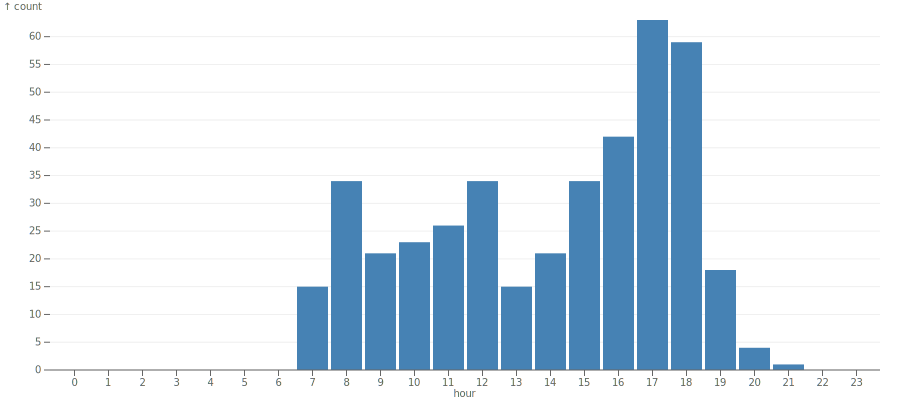

In [33]:
import { document } from "jsr:@manzt/jupyter-helper"
import * as Plot from "npm:@observablehq/plot";

// export function plotBarPlot(
//   records: Record<string|number, string|number>, 
//   xCol: string, 
//   yCol: string, 
//   document: any,
//   tickFormat?: CallableFunction) {
//   tickFormat = tickFormat || ((d: number) => d);


// }

const groupedByHour = transformedDf
  .groupBy("hour")
  .agg(pl.col("count").sum())
console.log(groupedByHour.toString())
// plotBarPlot(groupedByHour.toRecords(), "hour", "duration_minutes", document)


Plot.plot({
  width: 900,
  marginLeft: 50,
  marks: [
    Plot.barY(groupedByHour.toRecords() as unknown as Plot.Data, {
      x: "hour",
      y: "count",
      fill: "steelblue",
    }),
    Plot.ruleY([0]),
  ],
  x: {
    label: "hour",
    domain: [...Array(24)].map((_, index) => index)
    // tickFormat: d => tickFormat(d),
  },
  y: {
    label: "count",
    grid: true,

  },
  style: {
    color: "#666",
  },
  document,
}
);


shape: (12, 2)
┌───────┬──────────────────┐
│ month ┆ duration_minutes │
│ ---   ┆ ---              │
│ str   ┆ f64              │
╞═══════╪══════════════════╡
│ Mar   ┆ 569.0            │
│ Nov   ┆ 622.0            │
│ Dec   ┆ 363.0            │
│ Aug   ┆ 719.0            │
│ Jan   ┆ 575.0            │
│ …     ┆ …                │
│ Apr   ┆ 519.0            │
│ Sep   ┆ 797.0            │
│ Feb   ┆ 586.0            │
│ Jul   ┆ 728.0            │
│ Oct   ┆ 795.0            │
└───────┴──────────────────┘


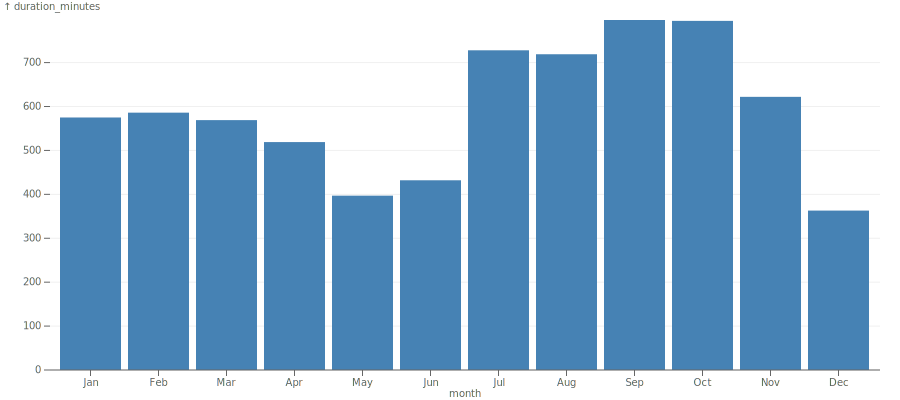

In [47]:
const groupedByMonth= transformedDf
  .filter(pl.col("datetime").dt.year().equals(2025))
  .groupBy("month")
  .agg(pl.col("duration_minutes").sum())
console.log(groupedByMonth.toString())
// plotBarPlot(groupedByHour.toRecords(), "hour", "duration_minutes", document)


Plot.plot({
  width: 900,
  marginLeft: 50,
  marks: [
    Plot.barY(groupedByMonth.toRecords() as unknown as Plot.Data, {
      x: "month",
      y: "duration_minutes",
      fill: "steelblue",
    }),
    Plot.ruleY([0]),
  ],
  x: {
    label: "month",
    domain: ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
  },
  y: {
    label: "duration_minutes",
    grid: true,
  },
  style: {
    color: "#666",
  },
  document,
});


shape: (50, 2)
┌─────────────┬───────┐
│ week_number ┆ count │
│ ---         ┆ ---   │
│ i8          ┆ f64   │
╞═════════════╪═══════╡
│ 3           ┆ 1.0   │
│ 8           ┆ 2.0   │
│ 24          ┆ 2.0   │
│ 37          ┆ 3.0   │
│ 19          ┆ 3.0   │
│ …           ┆ …     │
│ 25          ┆ 2.0   │
│ 7           ┆ 3.0   │
│ 12          ┆ 2.0   │
│ 5           ┆ 4.0   │
│ 33          ┆ 3.0   │
└─────────────┴───────┘


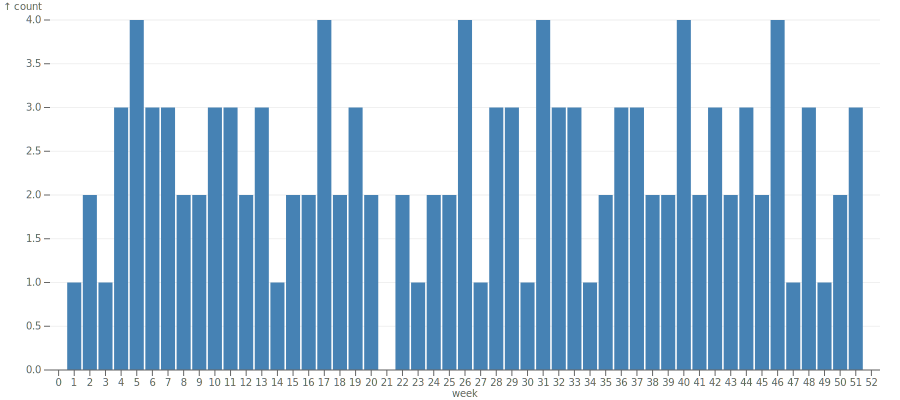

In [51]:
const groupedByWeek = transformedDf
  .filter(pl.col("datetime").dt.year().equals(2025))
  .groupBy("week_number")
  .agg(pl.col("count").sum())
console.log(groupedByWeek.toString())
// plotBarPlot(groupedByHour.toRecords(), "hour", "duration_minutes", document)


Plot.plot({
  width: 900,
  marginLeft: 50,
  marks: [
    Plot.barY(groupedByWeek.toRecords() as unknown as Plot.Data, {
      x: "week_number",
      y: "count",
      fill: "steelblue",
    }),
    Plot.ruleY([0]),
  ],
  x: {
    label: "week",
    domain: [...Array(53)].map((_, index) => index)
  },
  y: {
    label: "count",
    grid: true,
  },
  style: {
    color: "#666",
  },
  document,
});


shape: (3, 2)
┌────────────────────────────┬───────┐
│ gymLocationName            ┆ count │
│ ---                        ┆ ---   │
│ str                        ┆ f64   │
╞════════════════════════════╪═══════╡
│ Manchester Portland Street ┆ 15.0  │
│ Manchester Old Trafford    ┆ 4.0   │
│ Bolton                     ┆ 101.0 │
└────────────────────────────┴───────┘


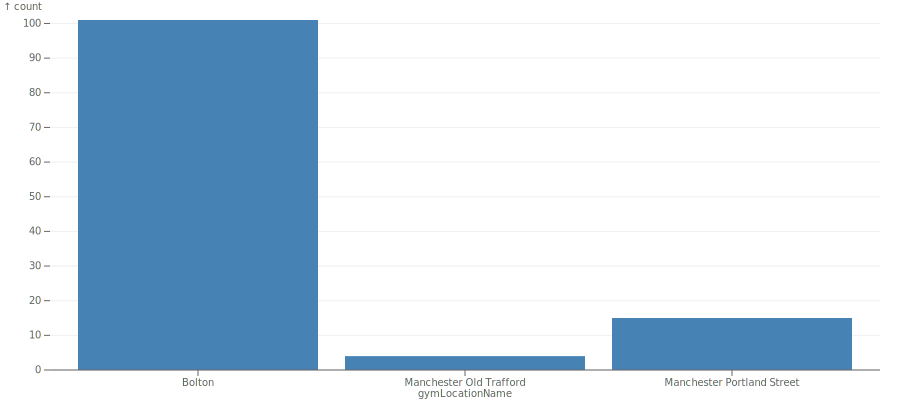

In [43]:
const groupedByLocation = transformedDf
  .filter(pl.col("datetime").dt.year().equals(2025))
  .groupBy("gymLocationName")
  .agg(pl.col("count").sum())
console.log(groupedByLocation.toString())
// plotBarPlot(groupedByHour.toRecords(), "hour", "duration_minutes", document)


Plot.plot({
  width: 900,
  marginLeft: 50,
  marks: [
    Plot.barY(groupedByLocation.toRecords() as unknown as Plot.Data, {
      x: "gymLocationName",
      y: "count",
      fill: "steelblue",
    }),
    Plot.ruleY([0]),
  ],
  x: {
    label: "gymLocationName",
  },
  y: {
    label: "count",
    grid: true,
  },
  style: {
    color: "#666",
  },
  document,
});
